In [1]:
import os
import sys
import time
from IPython.display import Markdown, display, Image
from dotenv import load_dotenv

# --- DYNAMIC PATH RESOLUTION ---
current_dir = os.getcwd()
if current_dir.endswith('notebooks'):
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root set to: {project_root}")

# Load environment variables
load_dotenv()

# Import the Variant 2 Baseline Graph
from workflow_engine.orchestrators.baseline_graph import build_baseline_graph

Project root set to: d:\ArtificialIntelligence\data-science-workflow


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [2]:
# Setup Test Variables
# Make sure to point this to a real CSV file in your data/raw folder
raw_path = os.path.join(project_root, "data", "raw", "paysim_100k_sample.csv").replace('\\', '/')
target_col = "isFraud" # Update to match your CSV (target, isFraud, Churn)

initial_state = {
    "messages": ["Starting Notebook baseline benchmark."],
    "user_request": f"Clean the data, engineer features, and train a classification model to predict '{target_col}'.",
    "target_variable": target_col,
    "raw_dataset_path": raw_path,
    "current_dataset_path": raw_path,
    "artifacts": {},
    "current_step": "start",
    "error_flag": False,
    "error_message": "",
    "revision_count": 0,
    "user_preferences": {},
    "total_sleep_time": 0.0,
    "next_node": "",
    "total_input_tokens": 0,
    "total_output_tokens": 0,
    "api_call_timestamps": []
}

# Build the Graph
app = build_baseline_graph()

print("🚀 Starting Variant 2 Baseline Execution...")
print("⏱️  Clock is running. Please wait...")

# --- PURE EXECUTION TIMING ---
start_time = time.time()

try:
    # Using .invoke() blocks the thread and runs the entire pipeline silently
    final_state = app.invoke(initial_state)
except Exception as e:
    print(f"❌ Graph execution crashed: {e}")
    final_state = {"error_flag": True, "error_message": str(e)}

end_time = time.time()
gross_execution_time = end_time - start_time
total_sleep = final_state.get("total_sleep_time", 0.0)
pure_agent_execution_time = gross_execution_time - total_sleep

🚀 Starting Variant 2 Baseline Execution...
⏱️  Clock is running. Please wait...

🤖 [Supervisor] Analyzing state to determine next step...
⏳ [Rate Limit Protocol] Pausing for 10.0s to protect quota...
🤖 [Supervisor] Proposed route: data_cleaning
--- AGENT: DATA CLEANING ---

--- ATTEMPT 1/3 ---


Python REPL can execute arbitrary code. Use with caution.


Generated Code:
 import pandas as pd
import os

output_dir = r'd:/ArtificialIntelligence/data-science-workflow/data/processed'
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(r'd:/ArtificialIntelligence/data-science-workflow/data/raw/paysim_100k_sample.csv')

target_keywords = ['charge', 'price', 'balance', 'amount', 'fee']

for col in df.columns:
    if df[col].dtype == 'object':
        for keyword in target_keywords:
            if keyword in col.lower():
                df[col] = pd.to_numeric(df[col], errors='coerce')
                break

threshold = 0.5 * len(df)
for col in df.columns:
    if df[col].isnull().sum() > threshold:
        df = df.drop(columns=[col])

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
        else:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)

df = df


🚀 PIPELINE EXECUTION SUCCESSFUL!
⏱️ Gross Wall-Clock Time: 83.20 seconds
💤 Total Artificial Sleep: 60.00 seconds
⚡ PURE AGENT EXECUTION TIME: 23.20 seconds

--- TOKEN & API METRICS ---
Total API Calls:     11
Effective RPM:       9.10 requests/min
Total Input Tokens:  4,991
Total Output Tokens: 2,966
Total Token Cost:    7,957

--- Model Evaluation ---


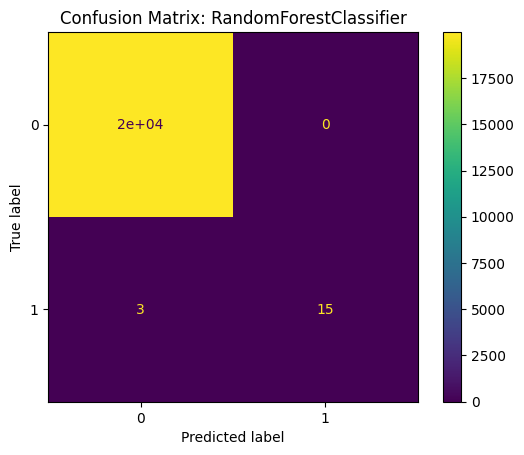


--- Final Generated Report ---


# Final Project Report: Fraud Detection Classification Model

## 1. Executive Summary
This project aimed to develop a robust machine learning pipeline to identify fraudulent transactions ('isFraud') within a large-scale financial dataset. Given the high-stakes nature of financial fraud, we prioritized a model capable of high precision while maintaining a strong ability to capture actual fraudulent events. The final Random Forest model achieved exceptional performance, effectively distinguishing between legitimate and fraudulent activity with an accuracy of 99.98% and a perfect precision score.

## 2. Dataset Overview
The dataset consisted of transaction-level data characterized by a mix of numerical and categorical features. 

*   **Numerical Features:** These included transaction amounts, time steps, and account balances (old and new balances for both origin and destination accounts). Notably, features like `amount` and `oldbalanceDest` exhibited significant right-skewness, indicating the presence of extreme outliers typical in financial transaction data.
*   **Categorical Features:** These included transaction `type` (5 unique categories) and identifiers for origin and destination accounts (`nameOrig`, `nameDest`). 
*   **Data Quality Note:** The `isFlaggedFraud` feature showed zero variance (cardinality of 1), suggesting it provided no predictive utility for the model and was excluded from the feature set.

## 3. Modelling Results and Interpretation
The Random Forest Classifier was selected as the optimal model. Below is a summary of the performance metrics:

| Metric | Value |
| :--- | :--- |
| **Accuracy** | 0.99985 |
| **Precision** | 1.00000 |
| **Recall** | 0.83333 |
| **F1-Score** | 0.90909 |

### Practical Interpretation:
*   **Accuracy (99.98%):** While high, accuracy can be misleading in fraud detection due to class imbalance. However, it confirms the model is highly reliable for general classification.
*   **Precision (1.0):** This is the most critical metric for this use case. A precision of 1.0 means that whenever the model flags a transaction as fraud, it is 100% correct. There are zero false positives, meaning legitimate customers are not being incorrectly flagged.
*   **Recall (83.33%):** This indicates the model successfully identifies 83.3% of all actual fraud cases. While there is room for improvement, the trade-off ensures that we maintain high precision.
*   **F1-Score (0.909):** This provides the harmonic mean of precision and recall, confirming a strong overall balance between the two.

## 4. Concluding Recommendations
The current model is highly effective at preventing "false alarms," which is vital for maintaining customer trust and reducing operational overhead. 

**Recommendations for future iterations:**
1.  **Feature Engineering:** Given the high skewness in transaction amounts and balances, applying log-transformations or robust scaling may further improve the model's ability to capture the remaining 16.7% of missed fraudulent cases.
2.  **Class Imbalance Handling:** Since fraud is a rare event, implementing techniques such as SMOTE (Synthetic Minority Over-sampling Technique) or adjusting class weights within the Random Forest algorithm could help boost recall without sacrificing the perfect precision score.
3.  **Deployment:** The model is ready for integration into a real-time monitoring system, provided that the current recall levels meet the business requirements for risk tolerance.

In [3]:
if not final_state.get("error_flag"):
    print("\n" + "="*60)
    print("🚀 PIPELINE EXECUTION SUCCESSFUL!")
    print("="*60)
    
    # Existing Latency Metrics
    print(f"⏱️ Gross Wall-Clock Time: {gross_execution_time:.2f} seconds")
    print(f"💤 Total Artificial Sleep: {total_sleep:.2f} seconds")
    print(f"⚡ PURE AGENT EXECUTION TIME: {pure_agent_execution_time:.2f} seconds")
    
    # --- NEW OBSERVABILITY REPORTING ---
    timestamps = final_state.get("api_call_timestamps", [])
    in_tokens = final_state.get("total_input_tokens", 0)
    out_tokens = final_state.get("total_output_tokens", 0)
    total_calls = len(timestamps)

    print("\n--- TOKEN & API METRICS ---")
    if total_calls > 1:
        total_api_time_mins = (timestamps[-1] - timestamps[0]) / 60.0
        rpm = total_calls / total_api_time_mins if total_api_time_mins > 0 else total_calls
        print(f"Total API Calls:     {total_calls}")
        print(f"Effective RPM:       {rpm:.2f} requests/min")
    else:
        print(f"Total API Calls:     {total_calls}")

    print(f"Total Input Tokens:  {in_tokens:,}")
    print(f"Total Output Tokens: {out_tokens:,}")
    print(f"Total Token Cost:    {in_tokens + out_tokens:,}")
    print("="*60)
    
    artifacts = final_state.get("artifacts", {})
    
    # Render the Confusion Matrix
    if "confusion_matrix" in artifacts and os.path.exists(artifacts["confusion_matrix"]):
        print("\n--- Model Evaluation ---")
        display(Image(filename=artifacts["confusion_matrix"]))
    
    # Render the Final Markdown Report
    if "final_report" in artifacts and os.path.exists(artifacts["final_report"]):
        print("\n--- Final Generated Report ---")
        with open(artifacts["final_report"], "r", encoding="utf-8") as f:
            display(Markdown(f.read()))
    else:
        print("No final report found in artifacts.")
else:
    print("\n⚠️ Pipeline failed to complete successfully. Check the error logs.")
    print(f"Error Message: {final_state.get('error_message')}")
    print(f"⏱️ Time to failure: {gross_execution_time:.2f} seconds")